In [663]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import StateSpace, lsim, hilbert
from scipy.io import loadmat,savemat
from scipy.optimize import minimize
from plasma_functions.load_shot import load_shot
from plasma_functions.compute_impedances import compute_impedances
from plasma_functions.circuit_model import circuit_model
from plasma_functions.moving_average import moving_average


# Load in shots

In [664]:
directory = "data/vacuum_shots_220816/good_shots" #pull in vacuum shots
trajectory_list,inputs_list,state_deriv_list,experiment_time = load_shot(directory, flux = True, plasma = False) #Flux circuits in vacuum

plasma_trajectory_list,plasma_inputs_list,plasma_state_deriv_list,experiment_time = load_shot('data/plasma_shots/flux_data/220816009',flux = True,plasma = True)

#pull in plasma shots
# new_plasma_shot_list,new_plasma_shot_inputs_list,new_plasma_shot_state_deriv_list,new_plasma_shot_time = load_shot('data/plasma_shots/flux_data/220816008',flux=True,plasma=True) 

# print(np.shape(new_plasma_shot_list[0]))

print(np.shape(plasma_trajectory_list[0]))
print(np.shape(trajectory_list))

(2256, 13)
(3, 2256, 12)


## We're only going to look at time in which the power supplies are not firing, and the circuit is ringing down. This should improve results?

In [665]:
states = trajectory_list[2] #circuit states for 220816005. Vacuum shot
derivs = state_deriv_list[2] # 'derivatives' for 220816005. This is the voltage across the inductors, and the current through the capacitors

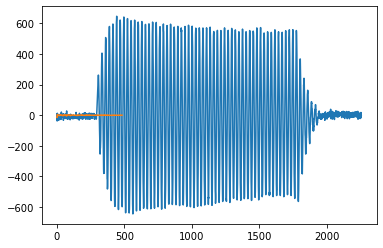

In [666]:
plt.plot(states[:,2])
plt.plot(inputs_list[0][-483:,0])

imp_L1 = 1.0552597783630547e-06, imp_L2 = 3.4432577018251603e-06
imp_L1 = 9.814175646903187e-07, imp_L2 = 3.043240203743628e-06
imp_L1 = 9.090597075621467e-07, imp_L2 = 3.988065392806638e-06
imp_L1 = 9.020720702147845e-07, imp_L2 = 3.222063657605722e-06
imp_L1 = 2.4216890204875637e-08, imp_L2 = -3.954004376541028e-07
imp_L1 = -3.272579917030745e-08, imp_L2 = 9.622125596644057e-08
imp_L1 = 8.343343577301464e-08, imp_L2 = -3.2815519881046485e-08
imp_L1 = 9.119124561171118e-08, imp_L2 = -2.1349110110747653e-07


c:\Users\ducks\Plasma-Shit\Python_Stuff\plasma_functions\compute_impedances.py:102: RuntimeWarning: invalid value encountered in true_divide
  M = -((-R21 * x1 * x12dot - x12dot * x2 + R21 * x12dot * x3 + R31 * x12dot * x3 +  L21 * x12dot * x3dot + R22 * x4 * x9dot + x5 * x9dot - R22 * x6 * x9dot -
c:\Users\ducks\Plasma-Shit\Python_Stuff\plasma_functions\compute_impedances.py:106: RuntimeWarning: divide by zero encountered in true_divide
  Mw = -((-R21 * x1 * x3dot - x2 * x3dot + R21 * x3 * x3dot + R31 * x3 * x3dot +  L21 * x3dot**2 + R22 * x12dot * x4 + x12dot * x5 - R22 * x12dot * x6 -  R32 * x12dot * x6
c:\Users\ducks\Plasma-Shit\Python_Stuff\plasma_functions\compute_impedances.py:106: RuntimeWarning: invalid value encountered in true_divide
  Mw = -((-R21 * x1 * x3dot - x2 * x3dot + R21 * x3 * x3dot + R31 * x3 * x3dot +  L21 * x3dot**2 + R22 * x12dot * x4 + x12dot * x5 - R22 * x12dot * x6 -  R32 * x12dot * x6
c:\Users\ducks\Plasma-Shit\Python_Stuff\plasma_functions\compute_impedanc

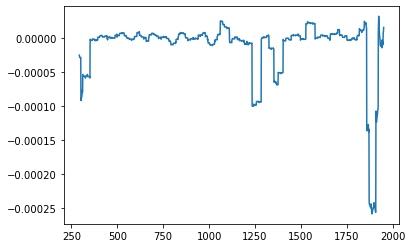

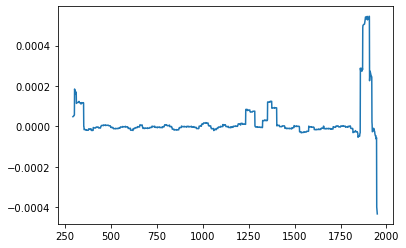

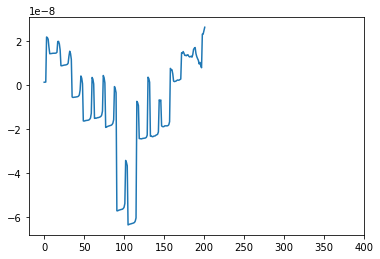

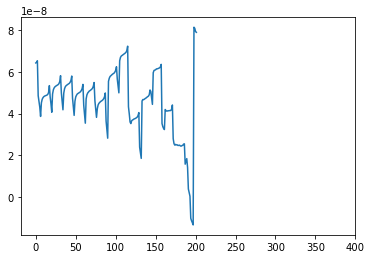

In [667]:
L1_arr, L2_arr = compute_impedances(states = states , derivs=derivs , frequency=18800, window_size=50, place = 1000)[0:2] #Calculate impedances for the flux circuits for given shot

M, Mw = compute_impedances(states= states[-482:,:] , derivs=derivs[-482:,:] , frequency=18800, window_size=25)[2:4] #Calculate mutual inductances for the shot. 



In [668]:
print(M_arr)

[9.01984439e-09 5.31243793e-08]


In [669]:
print(L1_arr)

[1.05525978e-06 9.81417565e-07 9.09059708e-07 9.02072070e-07]


In [670]:
print(L2_arr)

[3.44325770e-06 3.04324020e-06 3.98806539e-06 3.22206366e-06]


In [671]:
print(Mw[25])
print(M[25])

5.3124379316861584e-08
9.01984438930101e-09


In [672]:
L2_arr

array([3.44325770e-06, 3.04324020e-06, 3.98806539e-06, 3.22206366e-06])

In [673]:
# m1 = M > 0
# m2 = Mw > 0
# m_greater = M > Mw
# overlap = m1 & m2 & m_greater
# print(np.where(overlap == True))

In [674]:
print(L1_arr)
print(L2_arr)


[1.05525978e-06 9.81417565e-07 9.09059708e-07 9.02072070e-07]
[3.44325770e-06 3.04324020e-06 3.98806539e-06 3.22206366e-06]


In [736]:
Cap_arr = np.hstack([.98*96*10**-6,1.1*96*10**-6, 1.1*96*10**-6,1.1*96*10**-6]) #96 microfarad caps. Can use 1.15 and 1.13 on the last 2 for slightly better results
R_arr = np.ones((3,4)) * np.array([[.012],[.004],[.004]])
R_arr[:,1::] = R_arr[:,1::]/1.5
R_arr[:,2] = R_arr[:,2]/1
R_arr[:,3]/1.3
M_arr = np.array([M[25],Mw[25]])
# M_arr = [.161*2*10**-6,.1346*2*10**-6]
#Build vacuum model
A_analytic, B_analytic, C_analytic, D_analytic = circuit_model(L2_arr= L2_arr, L1_arr=L1_arr, Cap_arr= Cap_arr, R_arr = R_arr, M_arr = M_arr) #Build a vacuum state space model for the circuits


In [737]:

print(R_arr)

[[0.012      0.008      0.008      0.008     ]
 [0.004      0.00266667 0.00266667 0.00266667]
 [0.004      0.00266667 0.00266667 0.00266667]]


# We're also going to create a new plasma model here based on the new values of L2, and L1 that were obtained from the shot analysis

In [738]:
Mp = 150*10**-9 #Henry
Lp = L2_arr[0]
M_arr_plasma = np.hstack([M_arr,Mp])
print(M_arr_plasma)
L2_arr_plasma = np.hstack([L2_arr, Lp])
R_arr_plasma = np.hstack([R_arr, .005*np.ones((3,1))])
print(R_arr_plasma)


[9.01984439e-09 5.31243793e-08 1.50000000e-07]
[[0.012      0.008      0.008      0.008      0.005     ]
 [0.004      0.00266667 0.00266667 0.00266667 0.005     ]
 [0.004      0.00266667 0.00266667 0.00266667 0.005     ]]


In [739]:
A_analytic_plasma, B_analytic_plasma, C_analytic_plasma, D_analytic_plasma = circuit_model(
    L2_arr= L2_arr_plasma, L1_arr=L1_arr, Cap_arr= Cap_arr, R_arr = R_arr_plasma, M_arr = M_arr_plasma, Vacuum= False) #Build a plasma state space model for the circuits


In [740]:
print(np.linalg.eigvals(A_analytic_plasma))

[-6817.1771318 +114445.45628569j -6817.1771318 -114445.45628569j
 -5352.07689318+115776.32829097j -5352.07689318-115776.32829097j
 -5391.09980013+112931.04151052j -5391.09980013-112931.04151052j
 -4880.26154294+112823.37739387j -4880.26154294-112823.37739387j
 -2681.27633926     +0.j         -1423.75686972     +0.j
 -2005.51659351     +0.j         -1950.61292985     +0.j
 -1651.69656928     +0.j        ]


## Check stability of A matrix

In [741]:
print(np.linalg.eigvals(A_analytic))

[-6814.64837996+114422.86185901j -6814.64837996-114422.86185901j
 -5352.02605022+115755.63643288j -5352.02605022-115755.63643288j
 -5391.66331814+112912.03454901j -5391.66331814-112912.03454901j
 -4883.77152563+112790.64005856j -4883.77152563-112790.64005856j
 -2673.23459651     +0.j         -1634.70593131     +0.j
 -2001.13901634     +0.j         -1930.99463406     +0.j        ]


In [742]:
sys = StateSpace(A_analytic,B_analytic,C_analytic,D_analytic) #create statespace object


# Uncomment if you want to resave the analytic and plasma models

In [743]:
A_dict = {'A': A_analytic};
savemat('data/analytic_model_updated_params_9-25-24.mat', A_dict)

A_plasma_dict = {'A_plasma': A_analytic_plasma}
savemat('data/analytic_plasma_model_updated_params_9-26-24.mat', A_plasma_dict)

B_dict = {'B': B_analytic}
savemat('data/analytic_B_updated_params_9-26-24.mat', B_dict)

In [744]:
print(np.shape(inputs_list))
inputs = inputs_list[2][251::,:]
time = experiment_time[251::]

(3, 2256, 4)


In [745]:
[t,y,xout] = lsim(sys, inputs, time) #simulate vacuum model and try compare below to ground truth

2
5
8
11


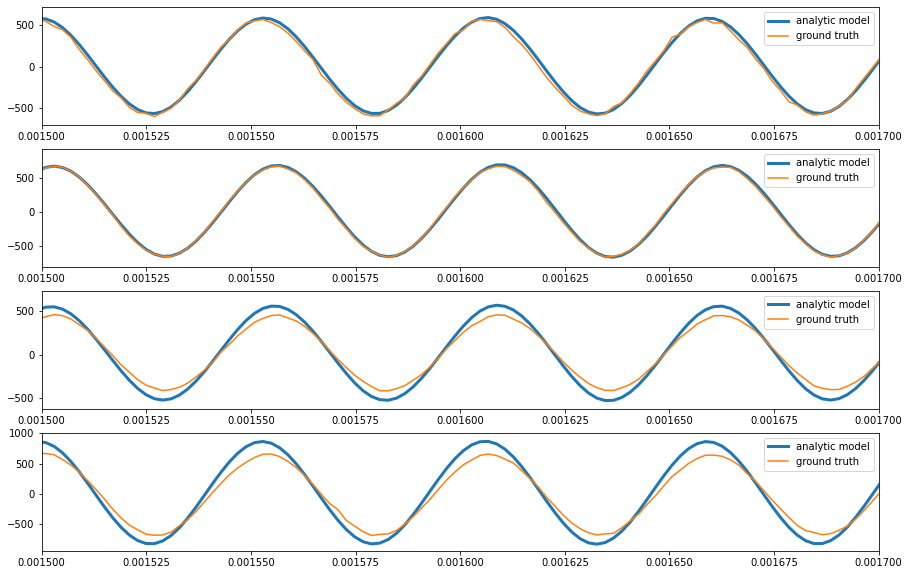

In [746]:
plt.figure(figsize=(15,10))
plot = 0
for k in range(2,12,3):
    plt.subplot(4,1,plot + 1)
    plt.plot(time,xout[:,k], linewidth = 3)
    plt.plot(time, states[251::,k])
    print(k)
    plt.legend(['analytic model', 'ground truth'])

    plt.xlim([.0015,.0017])
    plot = plot + 1

## Instead of trying to analytically solve for the mutual inductances, what if we try a brute force, probably nonlinear, optimization? :))))))

In [686]:
# def error_fun(M):
#     ss_model = vacuum_model(M_arr=M, L1_arr=L1_arr, L2_arr=L2_arr, Cap_arr=Cap_arr, R_arr=R_arr)
#     xout = lsim(ss_model, inputs,time)[2]
#     error = np.linalg.norm(xout-states)**2
#     return error

# M0 = M_arr
# result = minimize(error_fun,M0)